In [171]:
# ===============================
# STEP 1: Import Libraries & Load Data
# ===============================

# Basic Data Handling
import pandas as pd
import numpy as np

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [173]:
# Load Dataset
df=pd.read_excel(r"C:\Users\ak32a\Downloads\Anal-ysts\LTF Challenge data with dictionary.xlsx", sheet_name="TrainData")

In [174]:
# View structure
print("Data shape:", df.shape)
df.head()

Data shape: (47970, 105)


,FarmerID,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,Location,...,Rabi Seasons Agro Ecological Sub Zone in 2020,Rabi Seasons Seasonal average groundwater thickness (cm) in 2020,Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020,Night light index,Village score based on socio-economic parameters (Non normalised),Village score based on socio-economic parameters (0 to 100),"Village category based on socio-economic parameters (Good, Average, Poor)",Land Holding Index source (Total Agri Area/ no of people),Road density (Km/ SqKm),Target_Variable/Total Income
0,1002818465057450,MADHYA PRADESH,CENTRAL,M,BARELI,464668,RAISEN,Seoni,M,NaN,...,CENTRAL HIGHLANDS (MALWA AND BUNDELKHAND) HOT...,97.24,19.50,0.95,22.380262,33.527178,Poor,0.773129,0.00,1360000
1,1012300674433870,BIHAR,EAST,M,BANDRA,848125,MUZAFFARPUR,Namapur,M,NaN,...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,73.96,16.76,0.97,24.630262,37.173626,Poor,0.454140,0.00,807200
2,1013472263587380,MADHYA PRADESH,CENTRAL,M,MALHARGARH,458556,MANDSAUR,Billaud,M,NaN,...,CENTRAL HIGHLANDS ( MALWA ) GUJARAT PLAIN AND...,90.05,22.44,0.95,19.493313,28.848462,Poor,0.657040,0.00,500000
3,1019525480704050,MAHARASHTRA,WEST,M,RENAPUR,413527,LATUR,Renapur,M,NaN,...,DECCAN PLATU HOT SEMI-ARID ECO-REGION,94.64,21.48,0.98,31.836367,48.852156,Average,0.235615,2.49,558000
4,1021915867444260,MADHYA PRADESH,CENTRAL,F,KHURAI,470117,SAGAR,Singhpur,M,NaN,...,CENTRAL HIGHLANDS (MALWA AND BUNDELKHAND) HOT...,95.90,18.93,0.97,21.327371,31.820817,Poor,0.207264,0.00,800000


In [175]:
# ===============================
# STEP 2: Clean & Standardize Column Names
# ===============================

def clean_column(col_name):
    return (
        col_name.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

# Apply to all column names
df.columns = [clean_column(col) for col in df.columns]

# Preview cleaned column names
print("Cleaned Column Names:\n")
print(df.columns.tolist()[:15])  # Show first 15 as a sample


Cleaned Column Names:

['farmerid', 'state', 'region', 'sex', 'city', 'zipcode', 'district', 'village', 'marital_status', 'location', 'address_type', 'ownership', 'no_of_active_loan_in_bureau', 'avg_disbursement_amount_bureau', 'non_agriculture_income']


In [176]:
# ===============================
# STEP 4.5: Save Cleaned Dataset (Optional)
# ===============================

df.to_csv("cleaned_farmer_income_data.csv", index=False)
print("Cleaned dataset saved as cleaned_farmer_income_data.csv ✅")


Cleaned dataset saved as cleaned_farmer_income_data.csv ✅


In [177]:
# ===============================
# STEP 3: Missing Value Analysis
# ===============================

# Total missing values per column
missing_counts = df.isnull().sum()

# Percentage of missing values
missing_percent = (missing_counts / len(df)) * 100

# Combine into a summary table
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percent
})

# Filter only those with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing %', ascending=False)

print("Columns with missing values:\n")
missing_df.head(15)


Columns with missing values:



,Missing Count,Missing %
avg_disbursement_amount_bureau,20790,43.339587
location,17030,35.501355
address_type,17030,35.501355
ownership,17030,35.501355
perc_of_house_with_6plus_room,168,0.350219
women_15_19_mothers_or_pregnant_at_time_of_survey,168,0.350219
perc_of_pop_living_in_hh_electricity,168,0.350219
perc_households_with_pucca_house_that_has_more_than_3_rooms,168,0.350219
mat_roof_metal_gi_asbestos_sheets,168,0.350219
perc_of_wall_material_with_burnt_brick,168,0.350219


In [178]:
# there are only 13 columns that have missing values in them.

In [179]:
# ===============================
# STEP 4: Handling Missing Values
# ===============================
df[['location', 'address_type', 'ownership']] = df[['location', 'address_type', 'ownership']].fillna("missing_info")


In [180]:
# Dealing with Avg Disbursement Amt, missing values

# Step 1: Create a binary flag indicating presence of bureau loan data
df['has_loan_bureau_data'] = df['avg_disbursement_amount_bureau'].notna().astype(int)

# Step 2: Replace missing values in Avg_Disbursement_Amount_Bureau with 0
# (Alternatively, you could use -1 to make "missing" more explicit numerically)
df['avg_disbursement_amount_bureau'] = df['avg_disbursement_amount_bureau'].fillna(0)

# Optional: View distribution for sanity check
print(df[['avg_disbursement_amount_bureau', 'has_loan_bureau_data']].head(10))


   avg_disbursement_amount_bureau  has_loan_bureau_data
0                        0.000000                     0
1                    74000.000000                     1
2                   232999.857143                     1
3                        0.000000                     0
4                   138203.000000                     1
5                        0.000000                     0
6                        0.000000                     0
7                        0.000000                     0
8                   100000.000000                     1
9                    66187.000000                     1


In [181]:
# # Count of numeric columns
# num_numeric = (df.select_dtypes(include='number').columns)

# # Count of non-numeric columns
# num_non_numeric = (df.select_dtypes(exclude='number').columns)

# print(f"Numeric columns: {num_numeric}")
# print(f"Non-numeric columns: {num_non_numeric}")


In [182]:
# Count of numeric columns
num_numeric = len(df.select_dtypes(include='number').columns)

# Count of non-numeric columns
num_non_numeric = len(df.select_dtypes(exclude='number').columns)


print('number of num columns',num_numeric)
print('number of non num columns',num_non_numeric)


number of num columns 68
number of non num columns 38


In [184]:
# ===============================
# STEP X: Normalize & KNN Impute
# ===============================

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# 🔹 Define columns to use for KNN input
knn_input_columns = [
    'no_of_active_loan_in_bureau', 'avg_disbursement_amount_bureau', 'non_agriculture_income',
    'k022_proximity_to_nearest_mandi_km', 'k022_proximity_to_nearest_railway_km',
    'ko22_village_score_based_on_socio_economic_parameters_0_to_100',
    'k022_seasonal_average_rainfall_mm', 'r022_seasonal_average_rainfall_mm',
    'k021_seasonal_average_rainfall_mm', 'r021_seasonal_average_rainfall_mm',
    'r020_seasonal_average_rainfall_mm', 'k022_total_geographical_area_in_hectares_',
    'k022_net_agri_area_in_ha_', 'k022_net_agri_area_%_of_total_geog_area_',
    'kharif_seasons__irrigated_area_in_2022', 'kharif_seasons__cropping_density_in_2022',
    'kharif_seasons__agricultural_performance_in_2022', 'kharif_seasons__agricultural_score_in_2022',
    'kharif_seasons__seasonal_average_groundwater_thickness_cm_in_2022',
    'kharif_seasons__seasonal_average_groundwater_replenishment_rate_cm_in_2022',
    'rabi_seasons__season_irrigated_area_in_2022', 'rabi_seasons_cropping_density_in_2022',
    'rabi_seasons_agricultural_performance_in_2022', 'rabi_seasons_agricultural_score_in_2022',
    'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2022',
    'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2022',
    'rabi_seasons_kharif_season_irrigated_area_in_2021', 'rabi_seasons_cropping_density_in_2021',
    'rabi_seasons_agricultural_performance_in_2021', 'rabi_seasons_agricultural_score_in_2021',
    'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2021',
    'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2021',
    'kharif_seasons_kharif_season_irrigated_area_in_2021', 'kharif_seasons_cropping_density_in_2021',
    'kharif_seasons_agricultural_performance_in_2021', 'kharif_seasons_agricultural_score_in_2021',
    'kharif_seasons_seasonal_average_groundwater_thickness_cm_in_2021',
    'kharif_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2021',
    'kharif_seasons_kharif_season_irrigated_area_in_2020', 'kharif_seasons_cropping_density_in_2020',
    'kharif_seasons_agricultural_performance_in_2020', 'kharif_seasons_agricultural_score_in_2020',
    'kharif_seasons_seasonal_average_groundwater_thickness_cm_in_2020',
    'kharif_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2020',
    'rabi_seasons_kharif_season_irrigated_area_in_2020', 'rabi_seasons_cropping_density_in_2020',
    'rabi_seasons_agricultural_performance_in_2020', 'rabi_seasons_agricultural_score_in_2020',
    'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2020',
    'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2020',
    'night_light_index', 'village_score_based_on_socio_economic_parameters_non_normalised',
    'village_score_based_on_socio_economic_parameters_0_to_100',
    'land_holding_index_source_total_agri_area__no_of_people',
    'road_density_km__sqkm'
]

# 🔹 Define columns that have missing values and need to be imputed
knn_target_columns = [
    'perc_of_house_with_6plus_room', 'women_15_19_mothers_or_pregnant_at_time_of_survey',
    'perc_of_pop_living_in_hh_electricity', 'perc_households_with_pucca_house_that_has_more_than_3_rooms',
    'mat_roof_metal_gi_asbestos_sheets', 'perc_of_wall_material_with_burnt_brick',
    'households_with_improved_sanitation_facility', 'perc_households_do_not_have_kcc_with_the_credit_limit_of_50k',
    'total_land_for_agriculture'
]

# 🔹 Combine both to apply scaler and imputer
all_knn_columns = knn_input_columns + knn_target_columns

# 🔹 Subset the data
knn_df = df[all_knn_columns].copy()

# 🔹 Normalize
scaler = StandardScaler()
knn_scaled = scaler.fit_transform(knn_df)

# 🔹 Apply KNN imputer
imputer = KNNImputer(n_neighbors=5)
knn_imputed = imputer.fit_transform(knn_scaled)

# 🔹 Convert back to DataFrame
knn_imputed_df = pd.DataFrame(knn_imputed, columns=all_knn_columns)

# 🔹 Update only the target columns in the original df
df[knn_target_columns] = knn_imputed_df[knn_target_columns]

print("✅ KNN imputation completed for selected columns.")


✅ KNN imputation completed for selected columns.


In [185]:
df.to_csv("cleaned_knn_imputed_data.csv", index=False)


In [186]:
# Save the KNN Imputer for Later (e.g., for test data)
import joblib

joblib.dump(scaler, 'scaler_knn_imputer.pkl')
joblib.dump(imputer, 'knn_imputer.pkl')


['knn_imputer.pkl']

In [187]:
# Checking for column values similarity to remove similar columns
col_list=[ 'no_of_active_loan_in_bureau', 'avg_disbursement_amount_bureau', 'non_agriculture_income', 'total_land_for_agriculture', 'k022_nearest_mandi_name', 'k022_proximity_to_nearest_mandi_km', 'ko22_village_score_based_on_socio_economic_parameters_0_to_100', 'k022_village_category_based_on_socio_economic_parameters_good,_average,_poor', 'k022_seasonal_average_rainfall_mm', 'k022_ambient_temperature_min_&_max', 'r022_village_category_based_on_agri_parameters_good,_average,_poor', 'r022_seasonal_average_rainfall_mm', 'r022_ambient_temperature_min_&_max', 'k021_seasonal_average_rainfall_mm', 'k021_ambient_temperature_min_&_max', 'r021_seasonal_average_rainfall_mm', 'r021_ambient_temperature_min_&_max', 'r020_seasonal_average_rainfall_mm', 'r020_ambient_temperature_min_&_max', 'k022_total_geographical_area_in_hectares_', 'k022_net_agri_area_in_ha_', 'k022_net_agri_area_%_of_total_geog_area_', 'kharif_seasons__irrigated_area_in_2022', 'kharif_seasons__cropping_density_in_2022', 'kharif_seasons__agricultural_performance_in_2022', 'kharif_seasons__agricultural_score_in_2022', 'kharif_seasons__type_of_soil_in_2022', 'kharif_seasons__type_of_water_bodies_in_hectares_2022', 'kharif_seasons__agro_ecological_sub_zone_in_2022', 'kharif_seasons__seasonal_average_groundwater_thickness_cm_in_2022', 'kharif_seasons__seasonal_average_groundwater_replenishment_rate_cm_in_2022', 'rabi_seasons__season_irrigated_area_in_2022', 'rabi_seasons_cropping_density_in_2022', 'rabi_seasons_agricultural_performance_in_2022', 'rabi_seasons_agricultural_score_in_2022', 'rabi_seasons_type_of_soil_in_2022', 'rabi_seasons_type_of_water_bodies_in_hectares_2022', 'rabi_seasons_agro_ecological_sub_zone_in_2022', 'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2022', 'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2022', 'rabi_seasons_kharif_season_irrigated_area_in_2021', 'rabi_seasons_cropping_density_in_2021', 'rabi_seasons_agricultural_performance_in_2021', 'rabi_seasons_agricultural_score_in_2021', 'rabi_seasons_type_of_soil_in_2021', 'rabi_seasons_type_of_water_bodies_in_hectares_2021', 'rabi_seasons_agro_ecological_sub_zone_in_2021', 'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2021', 'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2021', 'kharif_seasons_kharif_season_irrigated_area_in_2021', 'kharif_seasons_cropping_density_in_2021', 'kharif_seasons_agricultural_performance_in_2021', 'kharif_seasons_agricultural_score_in_2021', 'kharif_seasons_type_of_soil_in_2021', 'kharif_seasons_type_of_water_bodies_in_hectares_2021', 'kharif_seasons_agro_ecological_sub_zone_in_2021', 'kharif_seasons_seasonal_average_groundwater_thickness_cm_in_2021', 'kharif_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2021', 'kharif_seasons_kharif_season_irrigated_area_in_2020', 'kharif_seasons_cropping_density_in_2020', 'kharif_seasons_agricultural_performance_in_2020', 'kharif_seasons_agricultural_score_in_2020', 'kharif_seasons_type_of_soil_in_2020', 'kharif_seasons_type_of_water_bodies_in_hectares_2020', 'kharif_seasons_agro_ecological_sub_zone_in_2020', 'kharif_seasons_seasonal_average_groundwater_thickness_cm_in_2020', 'kharif_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2020', 'rabi_seasons_kharif_season_irrigated_area_in_2020', 'rabi_seasons_cropping_density_in_2020', 'rabi_seasons_agricultural_performance_in_2020', 'rabi_seasons_agricultural_score_in_2020', 'rabi_seasons_type_of_soil_in_2020', 'rabi_seasons_type_of_water_bodies_in_hectares_2020', 'rabi_seasons_agro_ecological_sub_zone_in_2020', 'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2020', 'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2020', 'village_score_based_on_socio_economic_parameters_non_normalised', 'village_score_based_on_socio_economic_parameters_0_to_100', 'village_category_based_on_socio_economic_parameters_good,_average,_poor'] 

In [188]:
def check_all_column_similarities(df, col_list=None, threshold=0.95, include_self=False):
    
    from itertools import combinations_with_replacement, combinations
    import pandas as pd
    
    # Use all columns if col_list is not provided
    if col_list is None:
        col_list = df.columns.tolist()
    
    # Validate columns exist in DataFrame
    missing_cols = [col for col in col_list if col not in df.columns]
    if missing_cols:
        print(f"⚠️  Warning: These columns don't exist in DataFrame: {missing_cols}")
        col_list = [col for col in col_list if col in df.columns]
    
    if len(col_list) < 2:
        print("❌ Need at least 2 valid columns to compare")
        return {}
    
    results = {}
    total_comparisons = 0
    high_similarity_count = 0
    
    print(f"🔍 Checking similarity between {len(col_list)} columns...")
    print(f"📊 Threshold: {threshold * 100:.1f}%")
    print("-" * 80)
    
    # Choose iteration method based on include_self parameter
    if include_self:
        column_pairs = combinations_with_replacement(col_list, 2)
    else:
        column_pairs = combinations(col_list, 2)
    
    for col1, col2 in column_pairs:
        total_comparisons += 1
        
        # Handle case where both columns are the same (only if include_self=True)
        if col1 == col2:
            similarity = 1.0
        else:
            # Get valid (non-null) mask for both columns
            valid_mask = df[col1].notnull() & df[col2].notnull()
            valid_count = valid_mask.sum()
            
            if valid_count == 0:
                similarity = 0.0
                print(f"⚠️  {col1} vs {col2} → No valid data to compare")
                continue
            else:
                # Calculate similarity only on valid data
                similarity = (df[col1] == df[col2])[valid_mask].mean()
        
        similarity = round(similarity, 4)
        
        # Store and print results that meet threshold
        if similarity >= threshold:
            high_similarity_count += 1
            pair_key = f"{col1} vs {col2}"
            results[pair_key] = similarity
            
            # Enhanced output with more details
            valid_count = (df[col1].notnull() & df[col2].notnull()).sum() if col1 != col2 else len(df)
            total_rows = len(df)
            
            print(f"✅ {col1} vs {col2}")
            print(f"   📈 Similarity: {similarity * 100:.2f}%")
            print(f"   📋 Valid comparisons: {valid_count}/{total_rows} rows")
            print()
    
    # Summary statistics
    print("-" * 80)
    print(f"📊 SUMMARY:")
    print(f"   Total comparisons made: {total_comparisons}")
    print(f"   High similarity pairs found: {high_similarity_count}")
    print(f"   Percentage of high similarity pairs: {(high_similarity_count/total_comparisons)*100:.1f}%")
    
    if results:
        print(f"\n🏆 TOP SIMILAR PAIRS:")
        sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
        for i, (pair, sim) in enumerate(sorted_results[:5], 1):
            print(f"   {i}. {pair}: {sim*100:.2f}%")
    else:
        print(f"❌ No column pairs found with similarity >= {threshold*100:.1f}%")
    
    return results

In [189]:
check_all_column_similarities(df,col_list,0.95)

🔍 Checking similarity between 79 columns...
📊 Threshold: 95.0%
--------------------------------------------------------------------------------
✅ ko22_village_score_based_on_socio_economic_parameters_0_to_100 vs village_score_based_on_socio_economic_parameters_0_to_100
   📈 Similarity: 100.00%
   📋 Valid comparisons: 47970/47970 rows

✅ k022_village_category_based_on_socio_economic_parameters_good,_average,_poor vs village_category_based_on_socio_economic_parameters_good,_average,_poor
   📈 Similarity: 100.00%
   📋 Valid comparisons: 47970/47970 rows

✅ kharif_seasons__type_of_soil_in_2022 vs rabi_seasons_type_of_soil_in_2022
   📈 Similarity: 100.00%
   📋 Valid comparisons: 47970/47970 rows

✅ kharif_seasons__type_of_soil_in_2022 vs rabi_seasons_type_of_soil_in_2021
   📈 Similarity: 100.00%
   📋 Valid comparisons: 47970/47970 rows

✅ kharif_seasons__type_of_soil_in_2022 vs kharif_seasons_type_of_soil_in_2021
   📈 Similarity: 100.00%
   📋 Valid comparisons: 47970/47970 rows

✅ kharif_se

{'ko22_village_score_based_on_socio_economic_parameters_0_to_100 vs village_score_based_on_socio_economic_parameters_0_to_100': 1.0,
 'k022_village_category_based_on_socio_economic_parameters_good,_average,_poor vs village_category_based_on_socio_economic_parameters_good,_average,_poor': 1.0,
 'kharif_seasons__type_of_soil_in_2022 vs rabi_seasons_type_of_soil_in_2022': 1.0,
 'kharif_seasons__type_of_soil_in_2022 vs rabi_seasons_type_of_soil_in_2021': 1.0,
 'kharif_seasons__type_of_soil_in_2022 vs kharif_seasons_type_of_soil_in_2021': 1.0,
 'kharif_seasons__type_of_soil_in_2022 vs rabi_seasons_type_of_soil_in_2020': 1.0,
 'kharif_seasons__type_of_water_bodies_in_hectares_2022 vs rabi_seasons_type_of_water_bodies_in_hectares_2022': 1.0,
 'kharif_seasons__type_of_water_bodies_in_hectares_2022 vs rabi_seasons_type_of_water_bodies_in_hectares_2021': 1.0,
 'kharif_seasons__type_of_water_bodies_in_hectares_2022 vs kharif_seasons_type_of_water_bodies_in_hectares_2021': 1.0,
 'kharif_seasons__t

In [190]:
# columns to drop as they have same values throughout

drop_col = ['kharif_seasons_cropping_density_in_2021', 
            'village_score_based_on_socio_economic_parameters_0_to_100', 
            'rabi_seasons_type_of_soil_in_2021', 'kharif_seasons__type_of_soil_in_2022', 
            'rabi_seasons_type_of_soil_in_2022', 'kharif_seasons_type_of_soil_in_2020',
            'rabi_seasons_agro_ecological_sub_zone_in_2020', 'rabi_seasons_type_of_soil_in_2020', 
            'rabi_seasons_type_of_water_bodies_in_hectares_2021', 
            'rabi_seasons_type_of_water_bodies_in_hectares_2022', 
            'rabi_seasons_agro_ecological_sub_zone_in_2021', 
            'rabi_seasons_type_of_water_bodies_in_hectares_2020', 
            'kharif_seasons_kharif_season_irrigated_area_in_2021', 
            'kharif_seasons_type_of_water_bodies_in_hectares_2021',
            'kharif_seasons_type_of_water_bodies_in_hectares_2020',
            'kharif_seasons_agro_ecological_sub_zone_in_2021' ,
            'kharif_seasons_agro_ecological_sub_zone_in_2021' ,
            'rabi_seasons_agro_ecological_sub_zone_in_2022',
           'kharif_seasons_agro_ecological_sub_zone_in_2020']

In [191]:
# In addition to the above list, some columns are just increasing the noise in the data, such as
# zipcode, location, etc and some other are just repeating the data already given in numeric form. 
# So they are to be dropped.

In [192]:
columns_to_be_dropped = ['zipcode','location','city','village',
                         'r022_village_category_based_on_agri_parameters_good,_average,_poor',
                         'k022_village_category_based_on_agri_parameters_good,_average,_poor',
                         'k022_village_category_based_on_socio_economic_parameters_good,_average,_poor',
                         'village_category_based_on_socio_economic_parameters_good,_average,_poor']
drop_col.extend(columns_to_be_dropped)

In [193]:
df.drop(columns=drop_col, inplace=True)

In [194]:
# Now let's deal with water bodies, we are converting them to binary flags

In [195]:
# First, replace missing/None-like values with empty string
df['kharif_seasons__type_of_water_bodies_in_hectares_2022'] = df['kharif_seasons__type_of_water_bodies_in_hectares_2022'].fillna("").astype(str).str.lower()

# Define keywords to look for
keywords = ['river', 'water', 'reservoir', 'riverbank', 'wetland']

# Create binary columns for each keyword
for kw in keywords:
    df[f'near_{kw}'] = df['kharif_seasons__type_of_water_bodies_in_hectares_2022'].apply(lambda x: int(kw in x))

# Optional: Drop the original column
df.drop(columns=['kharif_seasons__type_of_water_bodies_in_hectares_2022'], inplace=True)

# Preview
df[[f'near_{kw}' for kw in keywords]].head()


,near_river,near_water,near_reservoir,near_riverbank,near_wetland
0,0,1,0,0,0
1,0,1,0,0,0
2,1,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


In [196]:
# Replace with actual column names
temp_cols = [
    'k022_ambient_temperature_min_&_max',
    'r022_ambient_temperature_min_&_max',
    'k021_ambient_temperature_min_&_max',
    'r021_ambient_temperature_min_&_max',
    'r020_ambient_temperature_min_&_max'
]

for col in temp_cols:
    df[[f"{col}_min", f"{col}_max"]] = df[col].str.split('/', expand=True).astype(float)


In [197]:
df.drop(columns=temp_cols, inplace=True)


In [222]:
# Encoding the Categorical columns, (where caardinality is low, label encoding is applied)
from sklearn.preprocessing import LabelEncoder

label_cols = [
    'region', 'sex', 'marital_status', 'address_type', 
    'ownership', 'kharif_seasons__agro_ecological_sub_zone_in_2022',
    'kharif_seasons_type_of_soil_in_2021']

for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))


In [224]:
# target encoding for high cardinality columns, namely:
# 'district':405, 'k022_nearest_mandi_name':890, 'state':17 

In [226]:
def target_encode_cv(df, col, target, n_splits=5, seed=42):
    df = df.copy()
    df[col + '_target_enc'] = np.nan
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    
    for train_idx, val_idx in kf.split(df):
        train, val = df.iloc[train_idx], df.iloc[val_idx]
        mapping = train.groupby(col)[target].mean()
        df.loc[df.index[val_idx], col + '_target_enc'] = val[col].map(mapping)
    
    # Safe assignment to avoid chained assignment warning
    global_mean = df[target].mean()
    df[col + '_target_enc'] = df[col + '_target_enc'].fillna(global_mean)
    
    return df


In [228]:
from sklearn.model_selection import KFold

for col in ['district', 'k022_nearest_mandi_name', 'state']:
    df = target_encode_cv(df, col, target='target_variable_total_income')


In [232]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_absolute_error
import numpy as np

# Label-encoded columns (low cardinality)
label_encoded_cols = [
    'region', 'sex', 'marital_status', 'address_type', 
    'ownership', 'kharif_seasons__agro_ecological_sub_zone_in_2022',
    'kharif_seasons_type_of_soil_in_2021'
]

# Target-encoded columns (high cardinality)
target_encoded_cols = [
    'district_target_enc', 
    'k022_nearest_mandi_name_target_enc', 
    'state_target_enc'
]

# Full list of encoded columns
encoded_cols = label_encoded_cols + target_encoded_cols

# # Define features and target
# X = df[encoded_cols]
# y = df['target_variable_total_income']


# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Drop target and irrelevant ID
num_cols = [col for col in num_cols if col not in ['farmerid', 'target_variable_total_income']]

# Final feature set
X_full = df[num_cols + encoded_cols]
y = df['target_variable_total_income']


# Define scoring metric
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Cross-validation score
scores = cross_val_score(LinearRegression(), X_full, y, cv=5, scoring=mae_scorer)

print("Cross-validated MAE scores (negative):", scores)
print("Average MAE:", -np.mean(scores))


Cross-validated MAE scores (negative): [-328188.61699979 -322507.51699254 -301952.51647185 -445586.2148531
 -386880.13048449]
Average MAE: 357022.999160354


In [234]:
df['target_variable_total_income'].describe()

count    4.797000e+04
mean     1.222255e+06
std      2.073935e+06
min      2.900000e+04
25%      7.200000e+05
50%      9.500000e+05
75%      1.295000e+06
max      8.000000e+07
Name: target_variable_total_income, dtype: float64

In [236]:
avg_income = df['target_variable_total_income'].mean()
print("MAE as % of Avg Income:", (356990 / avg_income) * 100)


MAE as % of Avg Income: 29.207481111875694


In [239]:
# Count of numeric columns
num_numeric = len(df.select_dtypes(include='number').columns)

# Count of non-numeric columns
num_non_numeric = (df.select_dtypes(exclude='number').columns)


print('number of num columns',num_numeric)
print('number of non num columns',num_non_numeric)


number of num columns 89
number of non num columns Index(['state', 'district', 'k022_nearest_mandi_name'], dtype='object')


In [242]:
#  Some engineered Features 
# ===============================
# 1. Relative Income Features
# ===============================
for geo in ['state', 'region', 'district']:
    avg_col = f'avg_income_by_{geo}'
    bin_col = f'above_avg_{geo}_income'

    df[avg_col] = df.groupby(geo)['target_variable_total_income'].transform('mean')
    df[bin_col] = (df['target_variable_total_income'] > df[avg_col]).astype(int)

# ===============================
# 2. Domain-Inspired Features
# ===============================

# Land-based
df['land_per_active_loan'] = df['total_land_for_agriculture'] / (df['no_of_active_loan_in_bureau'] + 1)
df['agri_income_ratio'] = df['target_variable_total_income'] / (df['non_agriculture_income'] + 1)

# Rainfall
rain_cols = [col for col in df.columns if 'rainfall_mm' in col]
df['avg_rainfall'] = df[rain_cols].mean(axis=1)

# Living conditions
df['housing_quality_score'] = (
    df['perc_of_house_with_6plus_room'] +
    df['perc_households_with_pucca_house_that_has_more_than_3_rooms'] +
    df['perc_of_pop_living_in_hh_electricity']
) / 3

# Groundwater
gw_cols = [col for col in df.columns if 'groundwater_thickness' in col]
df['groundwater_variability'] = df[gw_cols].std(axis=1)

# Market access
df['market_access_score'] = 1 / (df['k022_proximity_to_nearest_mandi_km'] + 1)
df['rail_access_score'] = 1 / (df['k022_proximity_to_nearest_railway_km'] + 1)


In [244]:
df.drop(columns=['district', 'k022_nearest_mandi_name', 'state'], inplace=True)


In [246]:
# Count of numeric columns
num_numeric = len(df.select_dtypes(include='number').columns)

# Count of non-numeric columns
num_non_numeric = (df.select_dtypes(exclude='number').columns)


print('number of num columns',num_numeric)
print('number of non num columns',num_non_numeric)


number of num columns 102
number of non num columns Index([], dtype='object')


# Model Training 

### XGBoost

In [250]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error

# Define features and target
X = df.drop(columns=['target_variable_total_income', 'farmerid'])  # Drop target + irrelevant ID
y = df['target_variable_total_income']

# Initialize XGBoost regressor
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Cross-validation MAE scorer
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Perform cross-validation
scores = cross_val_score(xgb_model, X, y, cv=5, scoring=mae_scorer)

print("Cross-validated MAE scores (negative):", scores)
print("Average MAE:", -np.mean(scores))


Cross-validated MAE scores (negative): [-144799.875    -132210.234375 -120447.8125   -191592.28125
 -132329.671875]
Average MAE: 144275.975


In [252]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# RMSE scorer (note: use negative MSE then take sqrt of mean later)
rmse_scores = cross_val_score(
    xgb_model, X, y, cv=5, scoring='neg_root_mean_squared_error'
)

# R2 Score
r2_scores = cross_val_score(
    xgb_model, X, y, cv=5, scoring='r2'
)

# MAPE (custom scorer)
mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)
mape_scores = cross_val_score(
    xgb_model, X, y, cv=5, scoring=mape_scorer
)

print("Average MAE:", 144275.975)  # Already known
print("Average RMSE:", -np.mean(rmse_scores))
print("Average R² Score:", np.mean(r2_scores))
print("Average MAPE (%):", -np.mean(mape_scores) * 100)


Average MAE: 144275.975
Average RMSE: 989493.9375
Average R² Score: 0.7187442183494568
Average MAPE (%): 9.034213870763779


### Dealing with outliers and improving the model

In [275]:
# Investigate Outliers

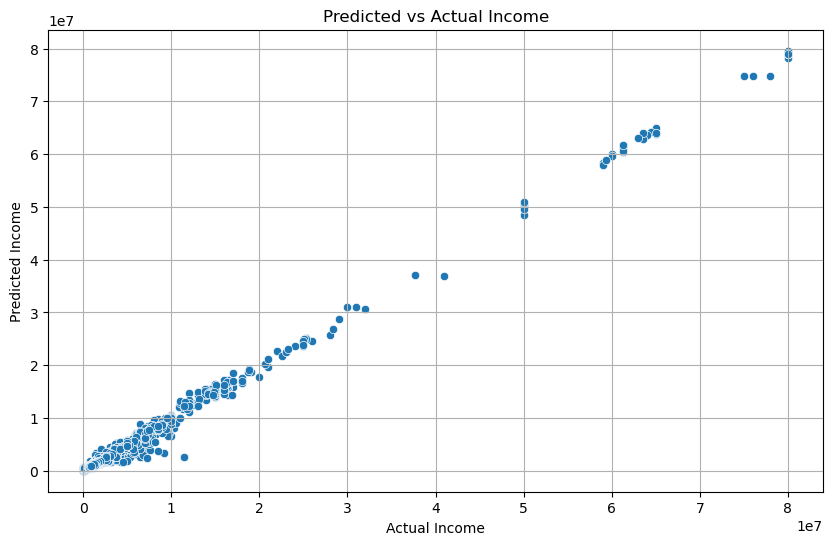

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of actual vs predicted
xgb_model.fit(X, y)
y_pred_full = xgb_model.predict(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=y_pred_full)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Predicted vs Actual Income")
plt.grid(True)
plt.show()


In [277]:
# . Feature Importance

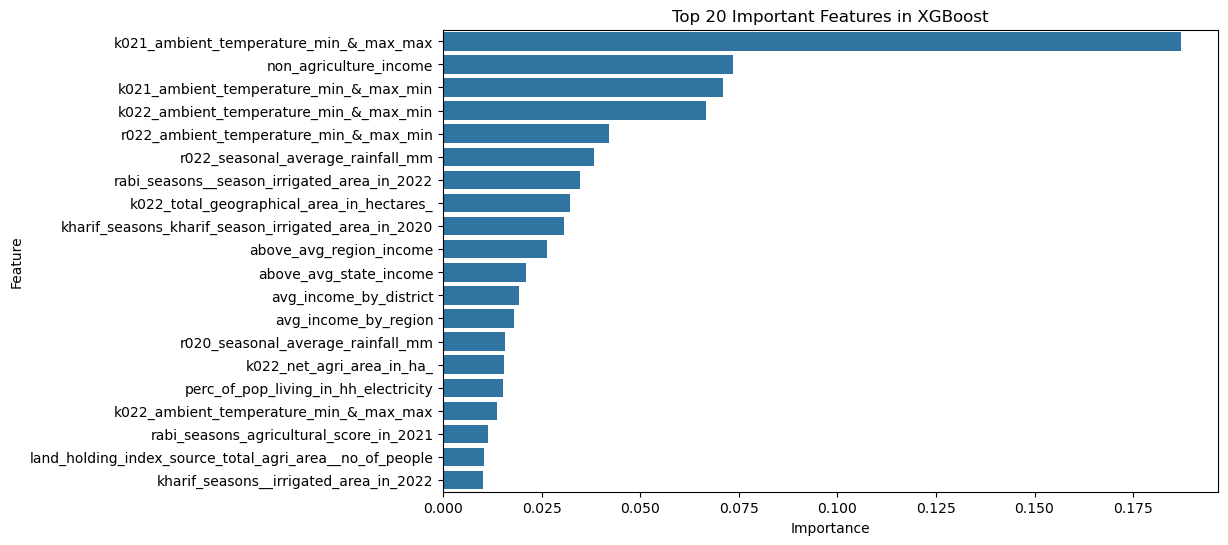

In [261]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fit final model
xgb_model.fit(X, y)

# Plot feature importances
importances = xgb_model.feature_importances_
features = X.columns

feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title("Top 20 Important Features in XGBoost")
plt.show()


In [273]:
# Log Transformation

In [268]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Features and log-transformed target
X = df.drop(columns=['target_variable_total_income', 'farmerid'])
y = df['target_variable_total_income']
y_log = np.log1p(y)  # log(1 + y) transformation to handle zeros

# Initialize XGBoost
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Cross-validated predictions on transformed target
y_pred_log = cross_val_predict(xgb_model, X, y_log, cv=5)

# Inverse transform predictions
y_pred_original = np.expm1(y_pred_log)  # exp(y) - 1

# Evaluate using original target (not log)
mae = mean_absolute_error(y, y_pred_original)
mse = mean_squared_error(y, y_pred_original)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred_original)
mape = mean_absolute_percentage_error(y, y_pred_original) * 100

# Print metrics
print(f"MAE: ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")


MAE: ₹118,847.61
RMSE: ₹1,230,113.48
R² Score: 0.6482
MAPE: 5.85%


In [279]:
# Step 1 (Error Analysis),

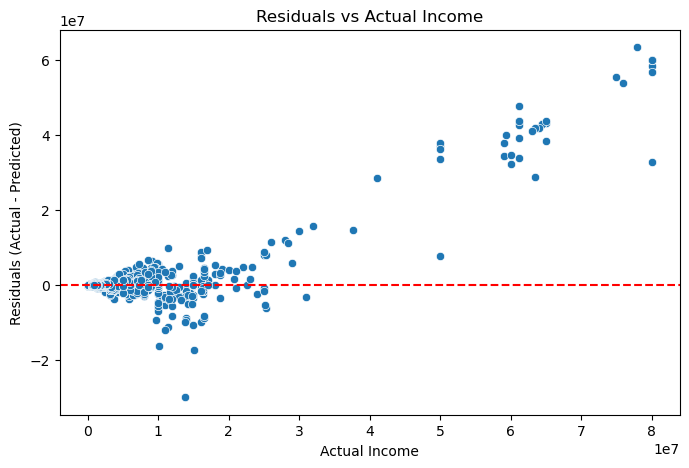

MAE by Income Bracket:
Income_Bracket
<1L        3.545735e+04
1L–10L     1.359451e+05
10L–20L    3.857888e+06
20L–40L    6.403763e+06
40L+       4.176176e+07
dtype: float64


C:\Users\ak32a\AppData\Local\Temp\ipykernel_18320\3400854542.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bracket_errors = df_eval.groupby('Income_Bracket').apply(lambda x: mean_absolute_error(x['Actual'], x['Predicted']))
C:\Users\ak32a\AppData\Local\Temp\ipykernel_18320\3400854542.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bracket_errors = df_eval.groupby('Income_Bracket').apply(lambda x: mean_absolute_error(x['Actual'], x['Predicted']))


In [271]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

# Residuals
residuals = y - y_pred_original

# 1. Residuals vs Actual Income
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Actual Income")
plt.xlabel("Actual Income")
plt.ylabel("Residuals (Actual - Predicted)")
plt.show()

# 2. Error by Income Bracket
df_eval = pd.DataFrame({'Actual': y, 'Predicted': y_pred_original})
df_eval['Income_Bracket'] = pd.cut(df_eval['Actual'], bins=[0, 1e6, 1e7, 2e7, 4e7, float('inf')], labels=['<1L', '1L–10L', '10L–20L', '20L–40L', '40L+'])
bracket_errors = df_eval.groupby('Income_Bracket').apply(lambda x: mean_absolute_error(x['Actual'], x['Predicted']))

print("MAE by Income Bracket:")
print(bracket_errors)


You're seeing heteroscedasticity: the spread of residuals (errors) increases with income.

The model is quite good at lower incomes, but as income increases, the prediction error widens dramatically.

This suggests the model underfits or overfits for certain segments, particularly in higher brackets.

💣 MAE by Income Bracket — Major Imbalance
Bracket	MAE
<1L	₹35,457
1L–10L	₹1.36L
10L–20L	₹38.57L
20L–40L	₹64.03L
40L+	₹4.17Cr (!)

1. Segmented Modeling
Train separate models per income bracket (e.g. <10L, 10–40L, 40L+).

In [284]:
# Example pseudo-segmentation
df_low = df[df['target_variable_total_income'] < 1e6]
df_mid = df[(df['target_variable_total_income'] >= 1e6) & (df['target_variable_total_income'] <= 4e6)]
df_high = df[df['target_variable_total_income'] > 4e6]

# Train separate XGBoost models on each


In [286]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def train_and_evaluate(segment_df, segment_name):
    # Drop irrelevant columns
    X = segment_df.drop(columns=['target_variable_total_income', 'farmerid'], errors='ignore')
    y = segment_df['target_variable_total_income']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Model
    model = XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n📊 Segment: {segment_name}")
    print(f"MAE: ₹{mae:,.2f}")
    print(f"RMSE: ₹{rmse:,.2f}")
    print(f"R² Score: {r2:.4f}")

    return model

# Train models
model_low = train_and_evaluate(df_low, 'Low Income (< ₹10L)')
model_mid = train_and_evaluate(df_mid, 'Mid Income (₹10L–₹40L)')
model_high = train_and_evaluate(df_high, 'High Income (> ₹40L)')



📊 Segment: Low Income (< ₹10L)
MAE: ₹18,604.12
RMSE: ₹32,442.88
R² Score: 0.9500

📊 Segment: Mid Income (₹10L–₹40L)
MAE: ₹51,893.60
RMSE: ₹95,119.74
R² Score: 0.9635

📊 Segment: High Income (> ₹40L)
MAE: ₹1,117,821.88
RMSE: ₹2,215,510.91
R² Score: 0.9220


In [288]:
# saving the model for future reference using joblib
import joblib

joblib.dump(model_low, 'xgb_model_low.pkl')
joblib.dump(model_mid, 'xgb_model_mid.pkl')
joblib.dump(model_high, 'xgb_model_high.pkl')


['xgb_model_high.pkl']

### Hypertuning

In [290]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def tune_xgb_model(segment_df, segment_name):
    print(f"\n🔍 Tuning model for: {segment_name}")

    X = segment_df.drop(columns=['target_variable_total_income', 'farmerid'], errors='ignore')
    y = segment_df['target_variable_total_income']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Parameter grid
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0]
    }

    base_model = XGBRegressor(random_state=42, n_jobs=-1)

    search = RandomizedSearchCV(
        base_model,
        param_distributions=param_grid,
        n_iter=20,  # Increase if you want deeper tuning
        scoring='neg_mean_absolute_error',
        cv=3,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"✅ Best Params: {search.best_params_}")
    print(f"MAE: ₹{mae:,.2f}")
    print(f"RMSE: ₹{rmse:,.2f}")
    print(f"R² Score: {r2:.4f}")

    return best_model


In [292]:
xgb_low = tune_xgb_model(df_low, 'Low Income')
xgb_mid = tune_xgb_model(df_mid, 'Mid Income')
xgb_high = tune_xgb_model(df_high, 'High Income')



🔍 Tuning model for: Low Income
Fitting 3 folds for each of 20 candidates, totalling 60 fits
✅ Best Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
MAE: ₹10,023.27
RMSE: ₹23,766.55
R² Score: 0.9732

🔍 Tuning model for: Mid Income
Fitting 3 folds for each of 20 candidates, totalling 60 fits
✅ Best Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
MAE: ₹27,709.40
RMSE: ₹70,814.40
R² Score: 0.9797

🔍 Tuning model for: High Income
Fitting 3 folds for each of 20 candidates, totalling 60 fits
✅ Best Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
MAE: ₹817,038.50
RMSE: ₹1,857,957.00
R² Score: 0.9452


In [295]:
# saving the models
import joblib

joblib.dump(xgb_low, 'xgb_low_final.pkl')
joblib.dump(xgb_mid, 'xgb_mid_final.pkl')
joblib.dump(xgb_high, 'xgb_high_final.pkl')


['xgb_high_final.pkl']

### Cat Boost

In [301]:
pip install catboost



   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   - -------------------------------------- 3.4/102.4 MB 25.2 MB/s eta 0:00:04
   -- ------------------------------------- 7.3/102.4 MB 21.6 MB/s eta 0:00:05
   ------- -------------------------------- 18.1/102.4 MB 32.6 MB/s eta 0:00:03
   ---------- ----------------------------- 26.5/102.4 MB 34.3 MB/s eta 0:00:03
   ------------ --------------------------- 32.0/102.4 MB 32.2 MB/s eta 0:00:03
   ------------- -------------------------- 33.6/102.4 MB 28.8 MB/s eta 0:00:03
   -------------- ------------------------- 37.0/102.4 MB 26.4 MB/s eta 0:00:03
   --------------- ------------------------ 40.4/102.4 MB 25.4 MB/s eta 0:00:03
   ----------------- ---------------------- 44.0/102.4 MB 23.9 MB/s eta 0:00:03
   ------------------- -------------------- 48.8/102.4 MB 23.7 MB/s eta 0:00:03
   -------------------- ------------------- 51.9/102.4 MB 22.8 MB/s eta 0:00:03
   ---------------------- ----------------- 56.4/1

In [303]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def train_catboost_model(segment_df, segment_name):
    print(f"\n🐱 Training CatBoost for: {segment_name}")

    X = segment_df.drop(columns=['target_variable_total_income', 'farmerid'], errors='ignore')
    y = segment_df['target_variable_total_income']

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    cat_features = X.select_dtypes(include='object').columns.tolist()

    model = CatBoostRegressor(
        iterations=300,
        depth=8,
        learning_rate=0.1,
        loss_function='MAE',
        cat_features=cat_features,
        verbose=0,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)

    print(f"MAE: ₹{mae:,.2f}")
    print(f"RMSE: ₹{rmse:,.2f}")
    print(f"R² Score: {r2:.4f}")

    return model


In [305]:
cat_low = train_catboost_model(df_low, "Low Income")
cat_mid = train_catboost_model(df_mid, "Mid Income")
cat_high = train_catboost_model(df_high, "High Income")



🐱 Training CatBoost for: Low Income
MAE: ₹14,566.81
RMSE: ₹31,812.89
R² Score: 0.9519

🐱 Training CatBoost for: Mid Income
MAE: ₹47,434.98
RMSE: ₹108,735.05
R² Score: 0.9522

🐱 Training CatBoost for: High Income
MAE: ₹1,559,714.68
RMSE: ₹3,044,848.29
R² Score: 0.8527


In [307]:
import joblib

joblib.dump(cat_low, 'cat_low_final.pkl')
joblib.dump(cat_mid, 'cat_mid_final.pkl')
joblib.dump(cat_high, 'cat_high_final.pkl')


['cat_high_final.pkl']

### LightGBM

In [312]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 9.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [314]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def train_lgb_model(segment_df, segment_name):
    print(f"\n🌿 Training LightGBM for: {segment_name}")

    X = segment_df.drop(columns=['target_variable_total_income', 'farmerid'], errors='ignore')
    y = segment_df['target_variable_total_income']

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LGBMRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)

    print(f"MAE: ₹{mae:,.2f}")
    print(f"RMSE: ₹{rmse:,.2f}")
    print(f"R² Score: {r2:.4f}")

    return model


In [316]:
lgb_low = train_lgb_model(df_low, "Low Income")
lgb_mid = train_lgb_model(df_mid, "Mid Income")
lgb_high = train_lgb_model(df_high, "High Income")



🌿 Training LightGBM for: Low Income
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.056382 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20152
[LightGBM] [Info] Number of data points in the train set: 20536, number of used features: 100
[LightGBM] [Info] Start training from score 730706.464696
MAE: ₹9,753.58
RMSE: ₹18,761.43
R² Score: 0.9833

🌿 Training LightGBM for: Mid Income
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.143347 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20071
[LightGBM] [Info] Number of data points in the train set: 17213, number of used features: 100
[LightGBM] [Info] Start training from score 1461206.439552
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

### Correlation Heatmap

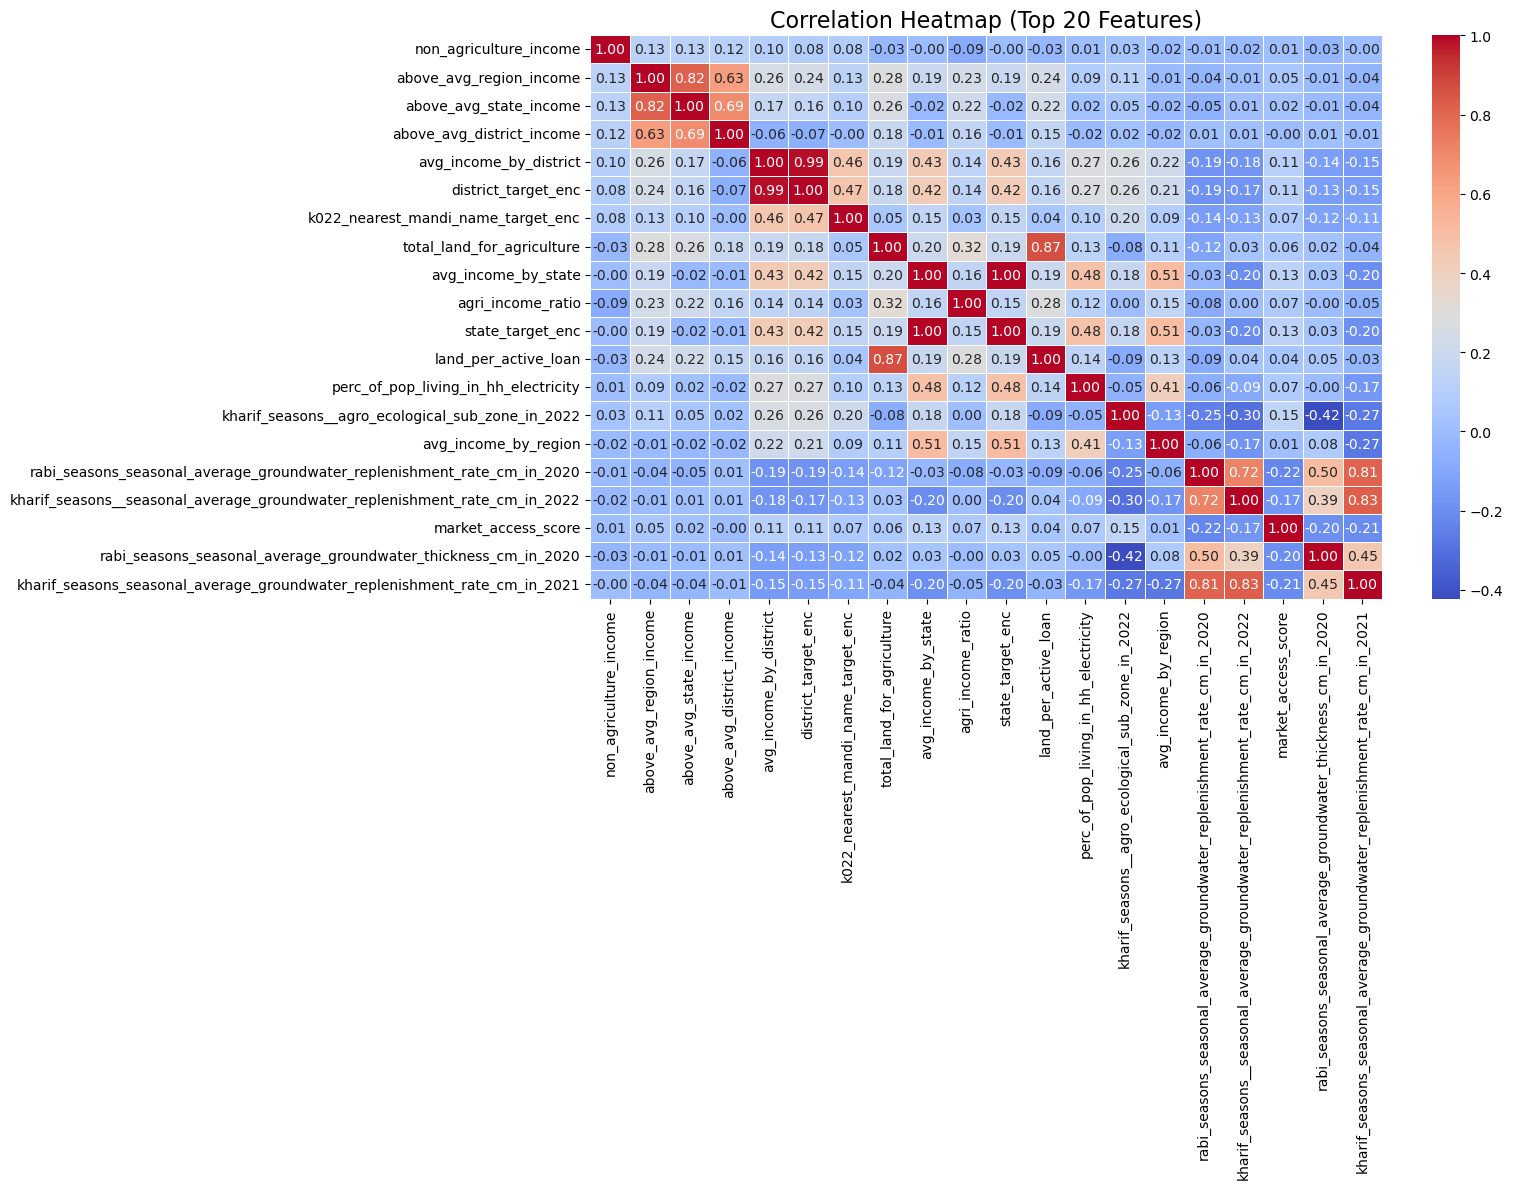

In [331]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# 2. Compute correlation matrix
corr_matrix = numeric_df.corr()

# 3. Select top N features most correlated with the target
target_corr = corr_matrix['target_variable_total_income'].abs().sort_values(ascending=False)
top_features = target_corr[1:21].index  # Exclude target itself and keep top 25

# 4. Filter correlation matrix to these features
filtered_corr = corr_matrix.loc[top_features, top_features]

# 5. Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(filtered_corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap (Top 20 Features)", fontsize=16)
plt.tight_layout()
plt.show()


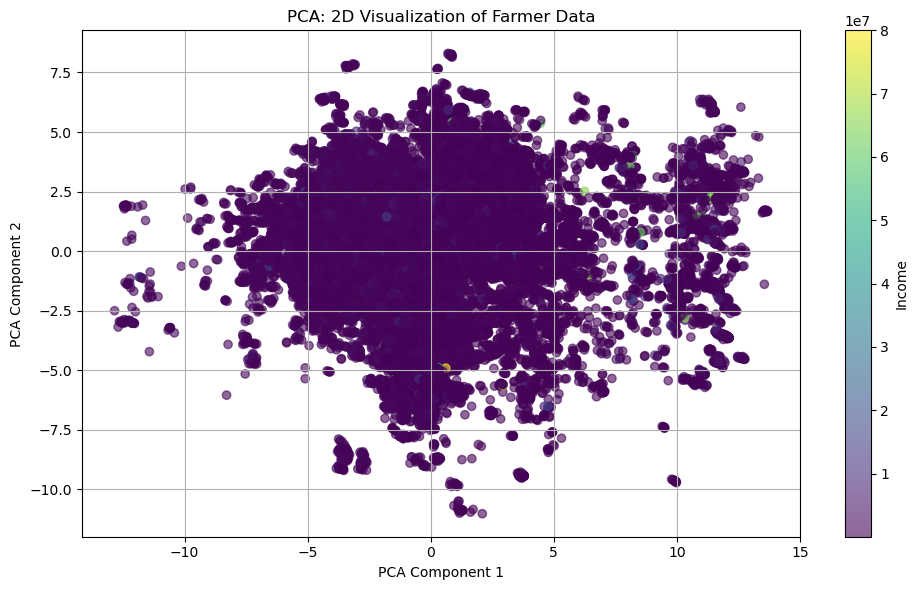

In [329]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Select only numeric features (excluding target + ID)
X_pca = df.drop(columns=['target_variable_total_income', 'farmerid'], errors='ignore')
X_pca = X_pca.select_dtypes(include='number')

# 2. Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# 3. Apply PCA
pca = PCA(n_components=2)
X_pca_components = pca.fit_transform(X_scaled)

# 4. Plot the PCA components
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_pca_components[:, 0],
    X_pca_components[:, 1],
    c=df['target_variable_total_income'],  # color by income
    cmap='viridis',
    alpha=0.6
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA: 2D Visualization of Farmer Data")
cbar = plt.colorbar(scatter)
cbar.set_label("Income")
plt.grid(True)
plt.tight_layout()
plt.show()


In [336]:
!conda install -c conda-forge shap -y

Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\ak32a\anaconda3

  added / updated specs:
    - shap


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2025.7.14  |       h4c7d964_0         152 KB  conda-forge
    certifi-2025.7.14          |     pyhd8ed1ab_0         156 KB  conda-forge
    conda-24.11.3              |  py312h2e8e312_0         1.1 MB  conda-forge
    cuda-cudart-12.9.79        |       he0c23c2_0         167 KB  conda-forge
    cuda-cudart_win-64-12.9.79 |       he0c23c2_0          23 KB  conda-forge
    cuda-version-12.9          |       h4f385c5_3          21 KB  conda-forge
    libexpat-2.6.3             |       he0c23c2_0         136 KB  conda-forge
    libsqlite-3.50.4           |       hf5d6505_0         1.2 MB  conda-forge
    libzlib-1.2.13           

In [337]:
import shap
import matplotlib.pyplot as plt

# Optional: sample to speed up computation
X_sample = X_low.sample(1000, random_state=42)

# SHAP Tree Explainer
explainer = shap.TreeExplainer(model_low)
shap_values = explainer.shap_values(X_sample)

# Summary bar plot
shap.summary_plot(shap_values, X_sample, plot_type="bar")


NameError: name 'X_low' is not defined